# Task 1: Data Cleaning & Preprocessing

This notebook demonstrates the process of importing, inspecting, cleaning, and validating the Sample Superstore dataset.

## 1. Import & Inspect

First, we import the necessary libraries and load the raw CSV data. We use `cp1252` encoding as it's common for this specific dataset. After loading, we inspect the shape, information, statistical summary, first few rows, and data types. Finally, we standardize the column names to `snake_case` for easier access.

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
# Trying cp1252 as the default utf-8 often fails with this raw data
df = pd.read_csv('../data/raw/superstore_raw.csv', encoding='cp1252')

# Display basic information
print(f"Dataset Shape: {df.shape}")
print("-" * 50)
df.info()


Dataset Shape: (9994, 21)
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null  

In [2]:
# Display statistical summary of numerical columns
df.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [3]:
# Show first 5 rows
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Display Data Types
print("Data Types before cleaning:")
print(df.dtypes)


Data Types before cleaning:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [5]:
# Standardize column names to snake_case
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')

print("\nStandardized Column Names:")
print(df.columns.tolist())



Standardized Column Names:
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


## 2. Identify Issues

Before cleaning, we must identify missing values, duplicate rows, inconsistent categorical entries, and verify data types (especially for dates). We will also visualize the missing data.

Missing Values Summary:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


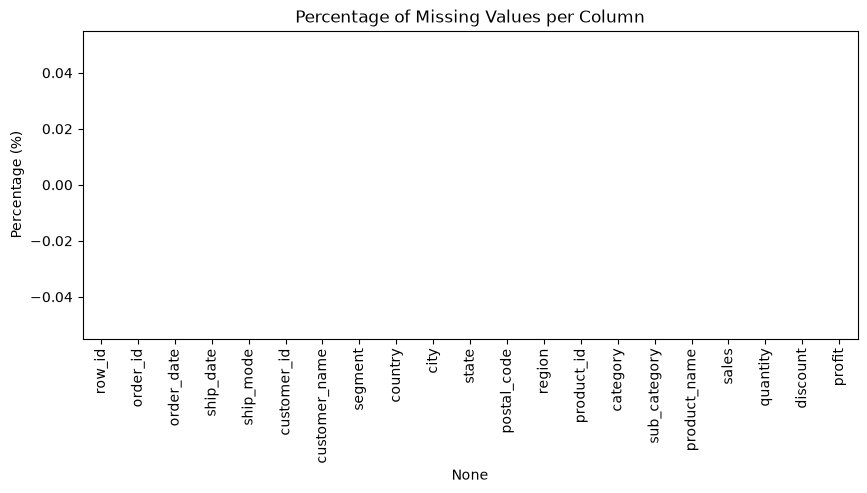

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage (%)': missing_percent})
print("Missing Values Summary:")
print(missing_df[missing_df['Missing Values'] > 0])

# Small bar chart for missing values
plt.figure(figsize=(10, 4))
sns.barplot(x=missing_percent.index, y=missing_percent.values)
plt.xticks(rotation=90)
plt.title("Percentage of Missing Values per Column")
plt.ylabel("Percentage (%)")
plt.show()


In [7]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print("\nExamples of duplicate rows:")
    display(df[df.duplicated(keep=False)].head())


Number of duplicate rows: 0


In [8]:
# Check unique values in key categorical columns for inconsistencies
categorical_cols = ['region', 'category', 'ship_mode', 'segment']
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].unique())



Unique values in 'region':
<ArrowStringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

Unique values in 'category':
<ArrowStringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

Unique values in 'ship_mode':
<ArrowStringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

Unique values in 'segment':
<ArrowStringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str


In [9]:
# Confirm date columns are strings (need conversion)
print("Data type of order_date:", df['order_date'].dtype)
print("Data type of ship_date:", df['ship_date'].dtype)


Data type of order_date: str
Data type of ship_date: str


## 3. Clean

In this phase, we address the issues found:
- **Missing Values**: We impute numerical values with the median (to handle outliers) and categorical with 'Unknown'. Note: postal_code sometimes has missing values depending on the region.
- **Duplicates**: We drop exact duplicate rows.
- **Categorical Text**: We strip whitespace and enforce consistent casing.
- **Dates**: We convert string dates to actual `datetime64` objects and compute `shipping_days`.
- **Anomalies**: We flag negative sales/profit values (negative profit represents a loss, which is logically valid, but negative sales would be an error).

In [10]:
# Missing values handling
# For numerical columns like postal_code (if missing), we can fill with a placeholder like 0 or drop. We will use a placeholder.
if df['postal_code'].isnull().sum() > 0:
    df['postal_code'] = df['postal_code'].fillna(0).astype(int)

# Drop exact duplicates and log
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} duplicate rows.")


Removed 0 duplicate rows.


In [11]:
# Standardize categorical text
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip().str.title()


/var/folders/1n/lyvm9j8j6457hfnvvhj1mdch0000gn/T/ipykernel_84543/1006847642.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [12]:
# Convert Dates to datetime64
# Format might be MM/DD/YYYY or DD/MM/YYYY, using infer_datetime_format equivalent
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')

# Add derived column: shipping_days
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days
print("Added derived column 'shipping_days'.")


Added derived column 'shipping_days'.


In [13]:
# Flag negative values
negative_sales = df[df['sales'] < 0]
negative_profit = df[df['profit'] < 0]

print(f"Rows with negative Sales: {len(negative_sales)} (Should ideally be 0)")
print(f"Rows with negative Profit (Losses): {len(negative_profit)}")

if not negative_profit.empty:
    print("Note: Negative profit is valid as it represents a business loss. We will keep these.")


Rows with negative Sales: 0 (Should ideally be 0)
Rows with negative Profit (Losses): 1871
Note: Negative profit is valid as it represents a business loss. We will keep these.


## 4. Validate

We verify that the dataset is clean, with no missing values or duplicates remaining. We also summarize the before/after dimensions.

In [14]:
# Re-run missing and duplicate checks
print("Missing values after cleaning:\n", df.isnull().sum().sum())
print("Duplicates after cleaning:\n", df.duplicated().sum())


Missing values after cleaning:
 0
Duplicates after cleaning:
 0


In [15]:
# Print before/after summary
print(f"Initial Shape: {initial_rows} rows, {df.shape[1] - 1} columns (excluding shipping_days)")
print(f"Final Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFinal Data Types:")
print(df.dtypes)


Initial Shape: 9994 rows, 21 columns (excluding shipping_days)
Final Shape: 9994 rows, 22 columns

Final Data Types:
row_id                    int64
order_id                    str
order_date       datetime64[us]
ship_date        datetime64[us]
ship_mode                   str
customer_id                 str
customer_name               str
segment                     str
country                     str
city                        str
state                       str
postal_code               int64
region                      str
product_id                  str
category                    str
sub_category                str
product_name                str
sales                   float64
quantity                  int64
discount                float64
profit                  float64
shipping_days             int64
dtype: object


## 5. Bonus — Save

Finally, we export the cleaned dataset to the `data/processed/` directory for use in subsequent tasks (Visualization and Customer Analysis).

In [16]:
import os

# Create directory if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# Export to CSV
save_path = '../data/processed/superstore_cleaned.csv'
df.to_csv(save_path, index=False)

print(f"Cleaned dataset saved successfully to: {save_path}")
print(f"Final saved shape: {df.shape}")


Cleaned dataset saved successfully to: ../data/processed/superstore_cleaned.csv
Final saved shape: (9994, 22)
